<a href="https://colab.research.google.com/github/diyapatel1225-cmyk/handwritten_digit_prediction/blob/main/handwritten_digit_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import the MNIST dataset loader
import tensorflow as tf
from tensorflow.keras.datasets import mnist

# Step 2: Load the dataset
dataset = mnist.load_data()

# Step 3: Split into training and testing sets
(x_train, y_train), (x_test, y_test) = dataset

# Step 4: Print shapes to check
print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


In [ ]:
# Step 1: Convert pixel values from 0–255 to 0–1
x_train = x_train / 255.0
x_test = x_test / 255.0

# Step 2: Reshape the data to add a channel dimension
# (because CNNs expect images with channels, like grayscale = 1 channel)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Step 3: Print shapes again to confirm
print("Training images after reshape:", x_train.shape)
print("Test images after reshape:", x_test.shape)


Training images after reshape: (60000, 28, 28, 1)
Test images after reshape: (10000, 28, 28, 1)


In [ ]:
# Step 1: Import the layers we need
from tensorflow.keras import layers, models

# Step 2: Create a Sequential model
model = models.Sequential()

# Step 3: Add the first convolutional layer
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

# Step 4: Add a pooling layer
model.add(layers.MaxPooling2D((2, 2)))

# Step 5: Add another convolutional layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Step 6: Add another pooling layer
model.add(layers.MaxPooling2D((2, 2)))

# Step 7: Flatten the output (convert 2D → 1D)
model.add(layers.Flatten())

# Step 8: Add a dense (fully connected) layer
model.add(layers.Dense(64, activation='relu'))

# Step 9: Add the final output layer (10 classes for digits 0–9)
model.add(layers.Dense(10, activation='softmax'))

# Step 10: Print the model summary
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 1: Choose the optimizer
# Adam is a smart optimizer that adjusts learning automatically
optimizer = 'adam'

# Step 2: Choose the loss function
# Sparse categorical crossentropy is used for multi-class classification (digits 0–9)
loss_function = 'sparse_categorical_crossentropy'

# Step 3: Choose the metric to track
# Accuracy tells us how often predictions are correct
metrics = ['accuracy']

# Step 4: Compile the model with these settings
model.compile(optimizer=optimizer,
              loss=loss_function,
              metrics=metrics)
# Step 1: Set the number of epochs (how many times the model sees the dataset)
epochs = 5

# Step 2: Train the model
history = model.fit(x_train, y_train,
                    epochs=epochs,
                    validation_data=(x_test, y_test))

# Step 3: Print training complete
print("Training finished!")


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 34ms/step - accuracy: 0.9549 - loss: 0.1473 - val_accuracy: 0.9809 - val_loss: 0.0603
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 32ms/step - accuracy: 0.9857 - loss: 0.0468 - val_accuracy: 0.9885 - val_loss: 0.0334
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9897 - loss: 0.0334 - val_accuracy: 0.9874 - val_loss: 0.0385
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9920 - loss: 0.0241 - val_accuracy: 0.9903 - val_loss: 0.0297
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9941 - loss: 0.0184 - val_accuracy: 0.9888 - val_loss: 0.0346
Training finished!


In [ ]:
# Step 1: Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)

# Step 2: Print the results
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


313/313 - 3s - 9ms/step - accuracy: 0.9888 - loss: 0.0346
Test Loss: 0.03455962613224983
Test Accuracy: 0.9887999892234802


In [ ]:
# Step 1: Pick one test image
sample_image = x_test[0]
sample_label = y_test[0]

# Step 2: Expand dimensions (model expects batch format)
import numpy as np
sample_image_expanded = np.expand_dims(sample_image, axis=0)

# Step 3: Make prediction
prediction = model.predict(sample_image_expanded)

# Step 4: Get the digit with highest probability
predicted_digit = np.argmax(prediction)

# Step 5: Print results
print("Actual digit:", sample_label)
print("Predicted digit:", predicted_digit)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Actual digit: 7
Predicted digit: 7


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


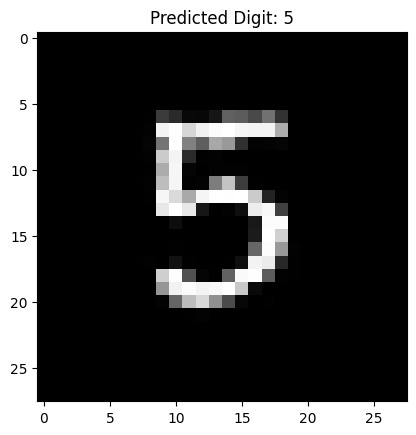

In [ ]:
# Step 1: Import helper libraries
import cv2   # for image processing
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Load your handwritten image (make sure it's 28x28 grayscale)
# Replace 'my_digit.png' with your file name
img = cv2.imread('digit5.png', cv2.IMREAD_GRAYSCALE)

# Step 3: Resize to 28x28 if needed
img_resized = cv2.resize(img, (28, 28))

# Step 4: Normalize pixel values (0–255 → 0–1)
img_normalized = img_resized / 255.0

# Step 5: Reshape to match model input (batch, height, width, channel)
img_ready = img_normalized.reshape(1, 28, 28, 1)

# Step 6: Predict using the trained model
prediction = model.predict(img_ready)
predicted_digit = np.argmax(prediction)

# Step 7: Show the image and result
plt.imshow(img_resized, cmap='gray')
plt.title(f"Predicted Digit: {predicted_digit}")
plt.show()


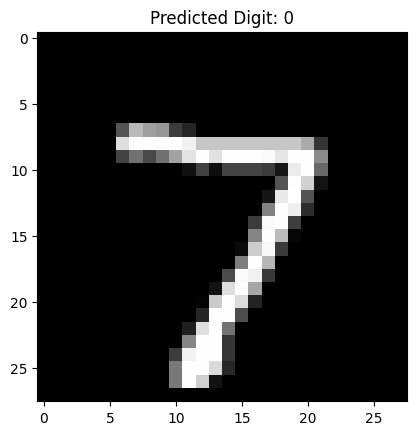

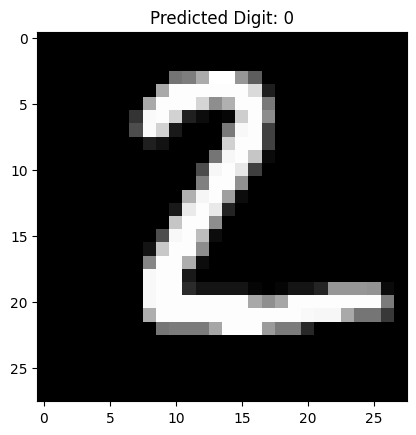

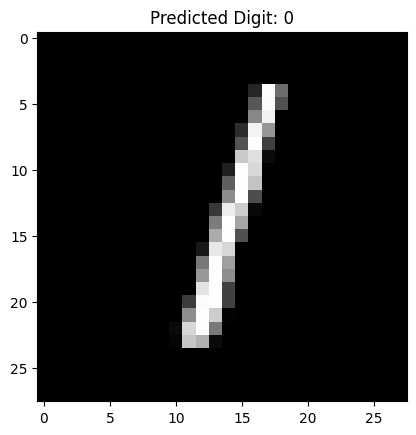

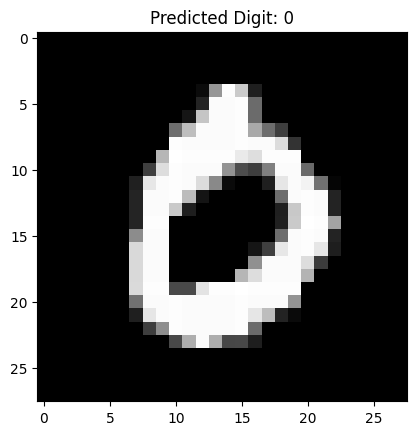

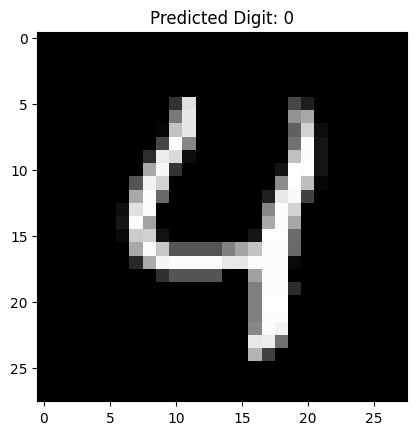

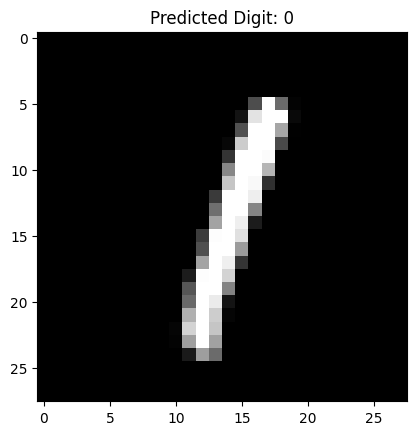

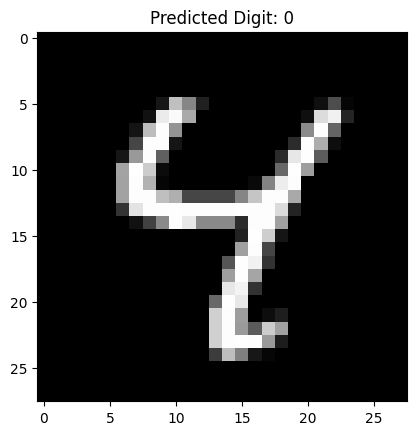

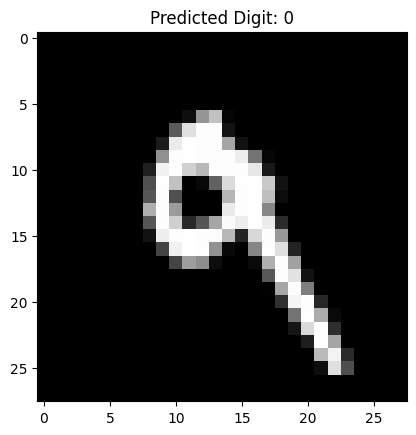

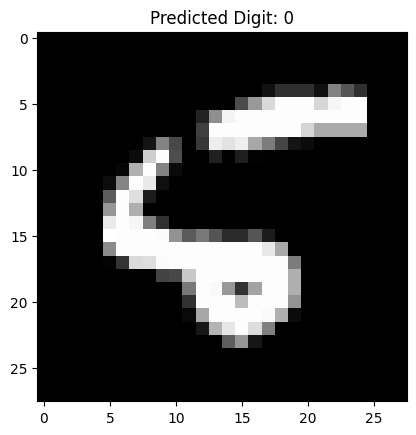

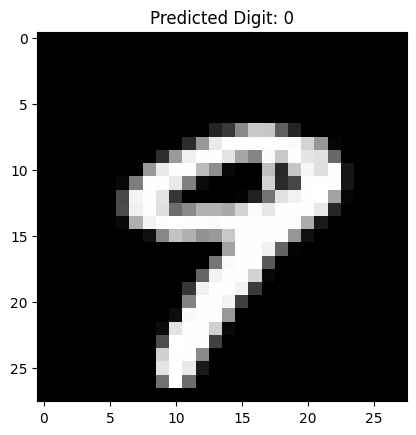

In [ ]:
for i in range(10):
  plt.imshow(x_test[i], cmap='gray')
  plt.title(f"Predicted Digit: {predicted_digit}")
  plt.show()